# 실습 1. 단일 선형 회귀

## 데이터
- `data/boston_housing_train.csv`
- 입력 feature: `RM` 평균 방 개수
- target: `MEDV` 주택 가격 중앙값

## 불러온 데이터와 컬럼 정보

### Boston Housing 데이터
- 파일 경로: `data/boston_housing_train.csv`
- 데이터 크기: 506행, 14컬럼
- 데이터 내용: 지역별 주택 가격과 주변 환경 정보를 담은 회귀 예제 데이터
- target 컬럼: `MEDV`

| 컬럼 | 의미 | 이번 실습 사용 |
|---|---|---|
| `CRIM` | 지역별 1인당 범죄율 |  |
| `ZN` | 25,000 제곱피트 초과 주거지역 비율 |  |
| `INDUS` | 비소매 상업지역 비율 |  |
| `CHAS` | 찰스강 인접 여부. 인접하면 1, 아니면 0 |  |
| `NOX` | 일산화질소 농도 |  |
| `RM` | 주택 1가구당 평균 방 개수 | 사용 feature |
| `AGE` | 1940년 이전 건축된 자가주택 비율 |  |
| `DIS` | 주요 고용 중심지까지의 가중 거리 |  |
| `RAD` | 방사형 고속도로 접근성 지수 |  |
| `TAX` | 재산세율 |  |
| `PTRATIO` | 학생/교사 비율 |  |
| `B` | 인구 통계 기반 지표. 수업에서는 해석하지 않음 |  |
| `LSTAT` | 저소득층 인구 비율 |  |
| `MEDV` | 주택 가격 중앙값. 단위는 1,000달러 | target |


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

housing_df = pd.read_csv('data/boston_housing_train.csv')

practice_df = housing_df[['RM', 'MEDV']].copy()
practice_df = practice_df.dropna()

X = practice_df[['RM']]
y = practice_df['MEDV']

print(practice_df.shape)
practice_df.head()


(506, 2)


,RM,MEDV
0,6.575,24.0
1,6.421,21.6
2,7.185,34.7
3,6.998,33.4
4,7.147,36.2


## 문제 1. 데이터 분리

`train_test_split()`으로 학습 데이터와 평가 데이터를 분리하세요.

### 요구사항
- `test_size=0.2` 사용
- `random_state=42` 사용
- 분리 결과의 shape 출력

### 힌트
- `X_train, X_test, y_train, y_test = train_test_split(...)` 형식을 사용함.

### 실행 결과

```text
X_train: (404, 1)
X_test: (102, 1)
y_train: (404,)
y_test: (102,)
```


In [14]:
# TODO: train_test_split()으로 학습/평가 데이터를 분리하세요.
# 조건: test_size=0.2, random_state=42
from sklearn.model_selection import train_test_split
X_train,  X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # 테스트 데이터의 비율(기본값 0.25)
    random_state=42 # 같은 난수가 나오게 고정
)

# TODO: 분리된 데이터의 shape를 출력하세요.

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(404, 1) (404,)
(102, 1) (102,)


## 문제 2. 모델 생성과 학습

`LinearRegression` 모델을 만들고 학습 데이터로 학습시키세요.

### 요구사항
- 모델 변수명은 `lin_reg`로 작성
- 학습 후 `coef_`, `intercept_` 출력

### 힌트
- `fit(X_train, y_train)`은 feature와 target의 관계를 학습함.

### 실행 결과

```text
회귀계수: [9.34830141]
절편: -36.24631889813795
```


In [15]:
# TODO: LinearRegression 모델을 생성하세요.
lin_reg = LinearRegression()


# TODO: 학습 데이터로 모델을 학습시키세요.
lin_reg.fit(X_train, y_train);

# TODO: 회귀계수와 절편을 출력하세요.
coef = lin_reg.coef_

intercept = lin_reg.intercept_ # 절편

print(coef)
print(intercept)

[9.34830141]
-36.24631889813792


## 문제 3. 평가와 예측

평가 데이터에서 예측값을 만들고 회귀 평가 지표를 계산하세요.

### 요구사항
- `predict()`로 `y_pred` 생성
- `R2`, `MAE`, `RMSE` 출력
- `RM=6.5`, `RM=7.0`일 때 예측값 출력

### 힌트
- 회귀에서 오차 지표는 낮을수록 좋고, `R2`는 높을수록 좋음.

### 실행 결과

```text
R2: 0.3707569232254778
MAE: 4.478335832064149
RMSE: 6.792994578778734
RM=6.5: 예측 MEDV=24.52
RM=7.0: 예측 MEDV=29.19
```


In [16]:
# TODO: X_test에 대한 예측값 y_pred를 생성하세요.

from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
# predict()를 여러 번 호출하지 않도록 학습셋/평가셋 예측값을 먼저 계산함.
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)


# TODO: R2, MAE, RMSE를 출력하세요.

# R^2는 평균 예측보다 모델이 얼마나 더 잘 설명하는지 보는 지표
print('R^2:', lin_reg.score(X_test, y_test))

# MAE: 오차 절댓값의 평균임. target 단위로 해석하기 쉬움.
print('MAE:', mean_absolute_error(y_test, y_test_pred))

# RMSE: MSE에 제곱근을 씌운 값임. 큰 오차에 민감하면서 target 단위로 해석 가능함.
print('RMSE:', root_mean_squared_error(y_test, y_test_pred))

# TODO: RM=6.5, RM=7.0인 새 데이터의 예측값을 출력하세요.
new_data = pd.DataFrame({'RM': [6.5, 7.0]})
new_pred = lin_reg.predict(new_data)

print(f'RM=6.5 예측값: {new_pred[0]:.2f}')
print(f'RM=7.0 예측값: {new_pred[1]:.2f}')

R^2: 0.3707569232254778
MAE: 4.478335832064147
RMSE: 6.792994578778734
RM=6.5 예측값: 24.52
RM=7.0 예측값: 29.19


## 문제 4. 산점도와 회귀선 시각화

실제 데이터 산점도 위에 모델이 학습한 회귀선을 그리세요.

### 요구사항
- x축: `RM`
- y축: `MEDV`
- 학습된 회귀선을 빨간색으로 표시

### 힌트
- 회귀선용 `x_line`을 만들고 `lin_reg.predict(x_line)`을 사용함.

### 실행 결과

![정답 실행 그래프](images/01_simple_linear_regression_problem_4_fig1.png)


C:\Users\playdata2\miniforge3\envs\pystudy_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


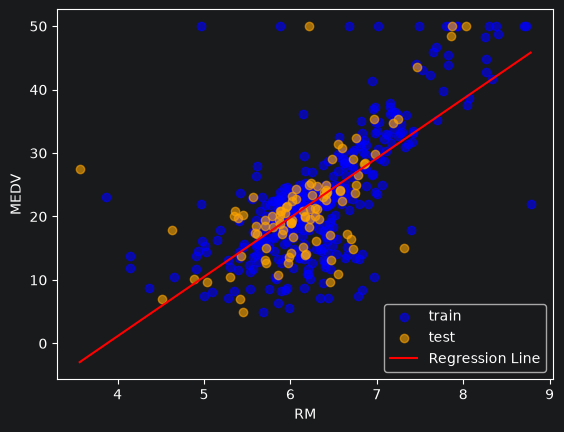

In [20]:
# TODO: 회귀선용 x_line을 생성하세요.
x_line = np.linspace(X['RM'].min(), X['RM'].max(), 100).reshape(-1, 1)

# TODO: lin_reg.predict()로 회귀선의 y값을 계산하세요.
y_line = lin_reg.predict(x_line)

# TODO: 산점도와 회귀선을 함께 그리세요.
plt.scatter(X_train['RM'], y_train, label='train', alpha=0.6, color='blue')
plt.scatter(X_test['RM'], y_test, label='test', alpha=0.6, color='orange')
plt.plot(x_line, y_line, color='red', label='Regression Line')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.legend()
plt.show()